In [1]:
import pandas as pd
import numpy as np
import prince
import matplotlib.pyplot as plt
import seaborn as sns

import data
clean
* distribution gaussienne centree reduite
* outliers
* enelver var corrélées
* 

QUANT
unidim - distr
outliers
bidim (corplot, pair plot)
multi (pca : val propres, graph axes, cercle correlation) --> clustering?

QUAL
MCA

QUAL-QUANT
MFA

### IMPORT DATA

In [2]:
# Load the latest version
df = pd.read_csv('data/spotify_songs.csv')

print("First 5 records:", df.head())

First 5 records:                  track_id                                         track_name  \
0  6f807x0ima9a1j3VPbc7VN  I Don't Care (with Justin Bieber) - Loud Luxur...   
1  0r7CVbZTWZgbTCYdfa2P31                    Memories - Dillon Francis Remix   
2  1z1Hg7Vb0AhHDiEmnDE79l                    All the Time - Don Diablo Remix   
3  75FpbthrwQmzHlBJLuGdC7                  Call You Mine - Keanu Silva Remix   
4  1e8PAfcKUYoKkxPhrHqw4x            Someone You Loved - Future Humans Remix   

       track_artist  track_popularity          track_album_id  \
0        Ed Sheeran                66  2oCs0DGTsRO98Gh5ZSl2Cx   
1          Maroon 5                67  63rPSO264uRjW1X5E6cWv6   
2      Zara Larsson                70  1HoSmj2eLcsrR0vE9gThr4   
3  The Chainsmokers                60  1nqYsOef1yKKuGOVchbsk6   
4     Lewis Capaldi                69  7m7vv9wlQ4i0LFuJiE2zsQ   

                                    track_album_name track_album_release_date  \
0  I Don't Care (with Justin B

### CLEAN DATA

In [3]:
print('=== Non-meaningful columns ===')
print('Remove the columns: ..... VALENTINO')


print('')
print('=== Missing values ===')
print('Columns containing missing values are:', list(df.columns[df.isnull().sum()!=0]))

print('')
print('track_name - Rate of missing values: {:.2f}%'.format(df['track_name'].isnull().sum()/df.shape[0]*100))
print('track_artist - Rate of missing values: {:.2f}%'.format(df['track_artist'].isnull().sum()/df.shape[0]*100))
print('track_album_name - Rate of missing values: {:.2f}%'.format(df['track_album_name'].isnull().sum()/df.shape[0]*100))

print('We cannot put the average value or the most common value and the rate of missing values is very low, hence we will just delete the rows that have empty data.')

df = df.dropna(subset=['track_name', 'track_artist', 'track_album_name'])

print('')
print('=== Checking ===')
#print(df.isnull().sum())
#print("New shape:", df.shape)
print('Columns containing missing values are:', list(df.columns[df.isnull().sum()!=0]))

=== Non-meaningful columns ===
Remove the columns: ..... VALENTINO

=== Missing values ===
Columns containing missing values are: ['track_name', 'track_artist', 'track_album_name']

track_name - Rate of missing values: 0.02%
track_artist - Rate of missing values: 0.02%
track_album_name - Rate of missing values: 0.02%
We cannot put the average value or the most common value and the rate of missing values is very low, hence we will just delete the rows that have empty data.

=== Checking ===
Columns containing missing values are: []


### OUTLIERS


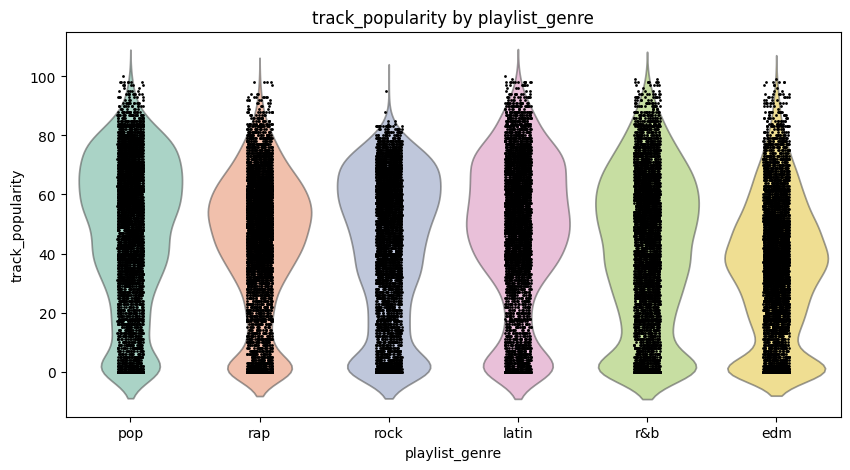

C:\Users\lenovoyoga914\AppData\Local\Temp\ipykernel_31196\1562046074.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


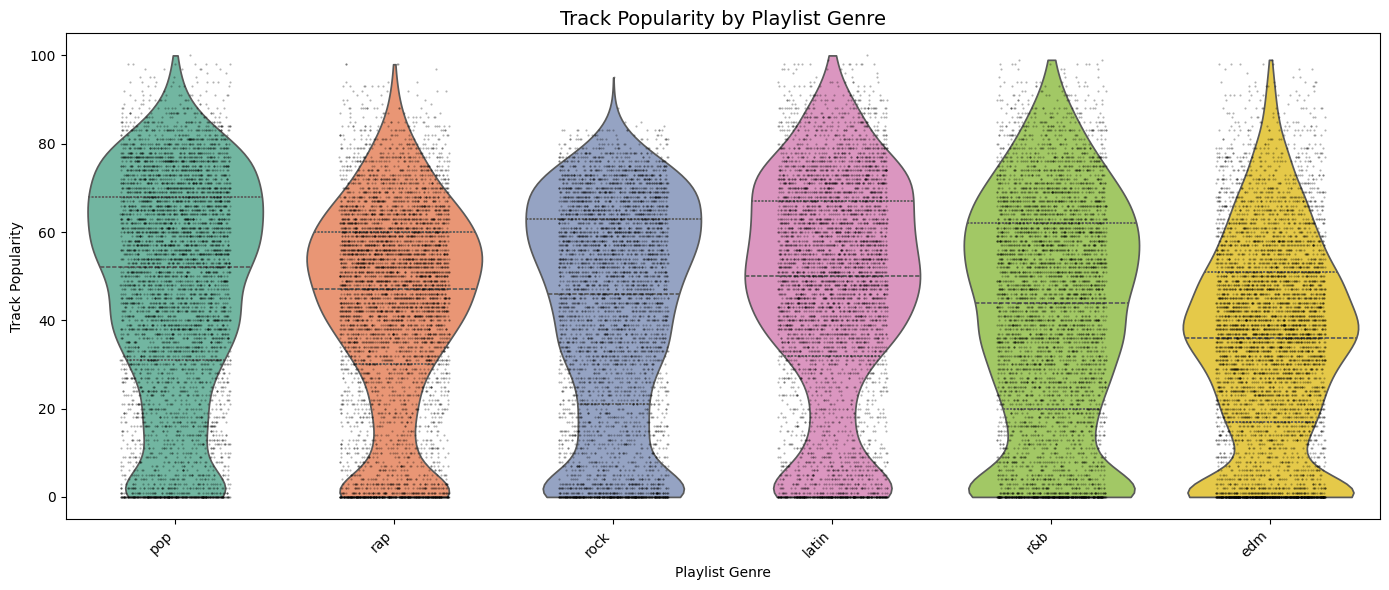

In [4]:
# Fare
plt.figure(figsize=(10,5))
sns.violinplot(data=df,
    x="playlist_genre", y="track_popularity", hue="playlist_genre", 
    palette="Set2", inner=None, alpha=0.6, legend=False, dodge=False
)
sns.stripplot(data=df,
    x="playlist_genre", y="track_popularity", color="black",
    size=2, jitter=True
)
plt.title("track_popularity by playlist_genre")
plt.show()

# IMPROVED VERSION #

plt.figure(figsize=(14,6))

sns.violinplot(
    data=df,
    x="playlist_genre",
    y="track_popularity",
    palette="Set2",
    inner="quartile",   # show quartiles inside violin
    cut=0
)

sns.stripplot(
    data=df,
    x="playlist_genre",
    y="track_popularity",
    color="black",
    size=1.5,
    jitter=0.25,
    alpha=0.3
)

plt.xticks(rotation=45, ha='right')
plt.title("Track Popularity by Playlist Genre", fontsize=14)
plt.xlabel("Playlist Genre")
plt.ylabel("Track Popularity")
plt.tight_layout()
plt.show()


--> no outliers detected

=== Outliers detection ===
We will remove 2698 lines
"New" spotify dataset shape: (30130, 23)


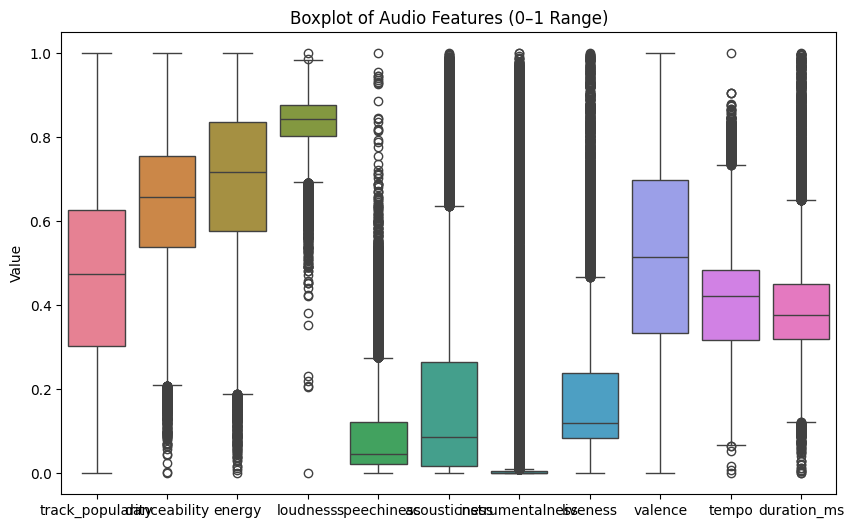

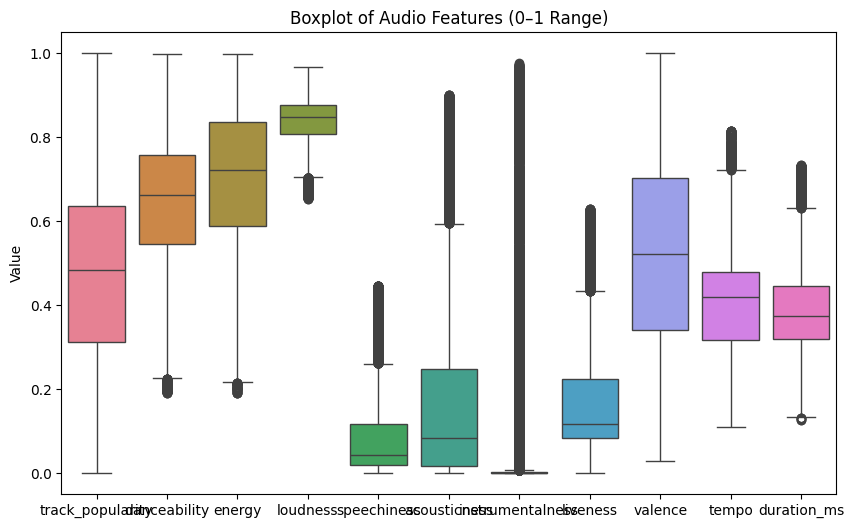

In [5]:
## TITANIC METHOD : NOUVEAUX CRITERES
print('=== Outliers detection ===')
cpt = np.sum(df['track_popularity']==0)
print('We will remove {:} lines'.format(cpt))

df = df[df['track_popularity'] != 0]
print('"New" spotify dataset shape:', df.shape)

#display(df)

## BOXPLOTS

# on souhaite détécter les outliers qui contiennent des valeur numériques extrêmes

# variables numériques
numeric_features = df.select_dtypes(include='number').columns.tolist()

# on supprime les variables mode et key car elles sont quantitatives
if 'mode' in numeric_features:
    numeric_features.remove('mode')
if 'key' in numeric_features:
    numeric_features.remove('key')

# on les ramène à une échelle comparable (notamment pour duration_ms)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[numeric_features] = scaler.fit_transform(df[numeric_features])

# PLOT
plt.figure(figsize=(10,6))
sns.boxplot(data=df[numeric_features])
plt.title("Boxplot of Audio Features (0–1 Range)")
plt.ylabel("Value")
plt.show()

## Remove data below 5th percentile and above 95th percentile
k=0.3
difference = df[numeric_features].quantile(0.95) - df[numeric_features].quantile(0.05)
lower_bounds = df[numeric_features].quantile(0.05) - k*difference
upper_bounds = df[numeric_features].quantile(0.95) + k*difference

mask = np.ones(len(df), dtype=bool)

for col in numeric_features:
    mask &= (df[col] >= lower_bounds[col]) & (df[col] <= upper_bounds[col])

df_clean = df[mask]


## BOXPLOTS AFTER CLEANING


plt.figure(figsize=(10,6))
sns.boxplot(data=df_clean[numeric_features])
plt.title("Boxplot of Audio Features (0–1 Range)")
plt.ylabel("Value")
plt.show()


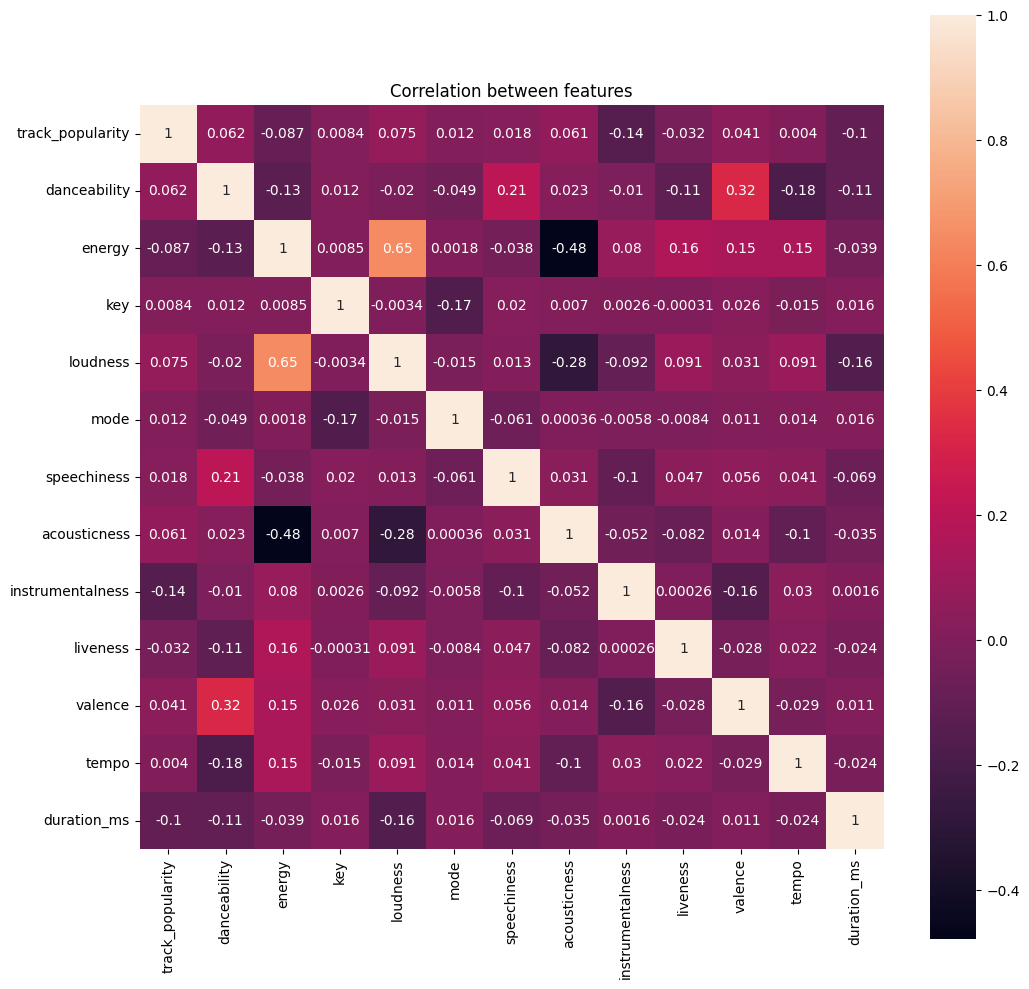

In [6]:
corr = df_clean.corr(numeric_only=True)

plt.figure(figsize=(12, 12))
sns.heatmap(corr, annot=True, square=True, cmap='rocket')
plt.title('Correlation between features')
plt.show()

## PCA

In [7]:
# Performing PCA
df_quanti = df_clean[numeric_features]
print("Quantitative features:", numeric_features)

pca = prince.PCA(
    n_components=3,
    rescale_with_mean=True,
    rescale_with_std=True,
    random_state=42
)
pca = pca.fit(df_quanti)

Quantitative features: ['track_popularity', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']


In [8]:
# Inertia by each axis
display(pca.eigenvalues_summary)
pca.scree_plot()

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,2.071,18.82%,18.82%
1,1.550,14.09%,32.92%
2,1.167,10.61%,43.52%


alt.Chart(...)

------------------- ADD JULIEN'S GRAPH WITH THE AFFINE FCT LINEAR PROP

The 3 first principal components do not really explain the variance, as we only get a 37% cumulative % of variance which is clearly not enough. However, we can still try to predict the musical genre or the track mode in PCA space by showing the projections of the points in the principal maps, colored accordingly.

  
Qualitative variable : key
Number of modalities: 12


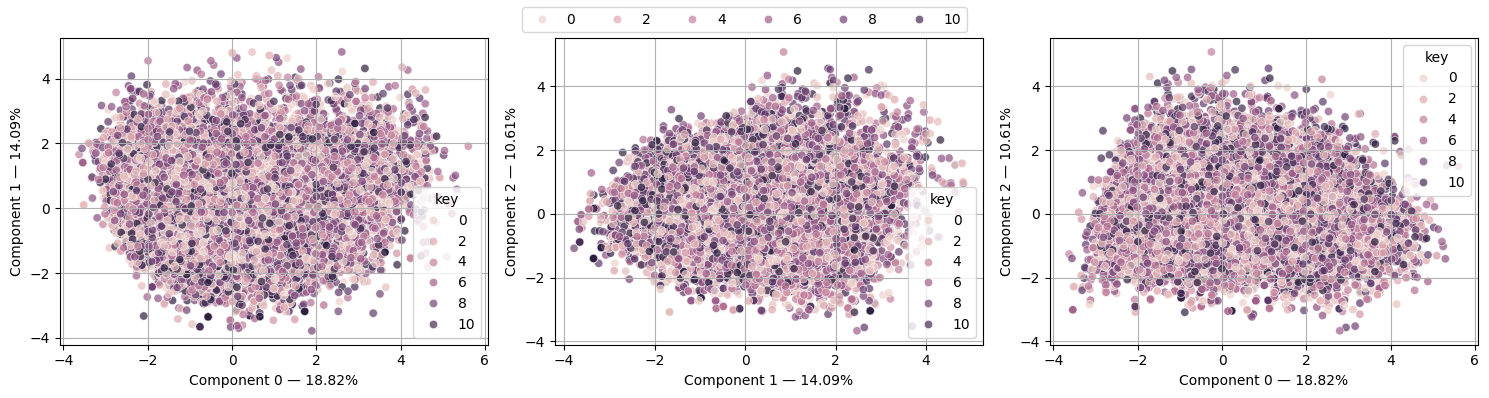

  
Qualitative variable : mode
Number of modalities: 2


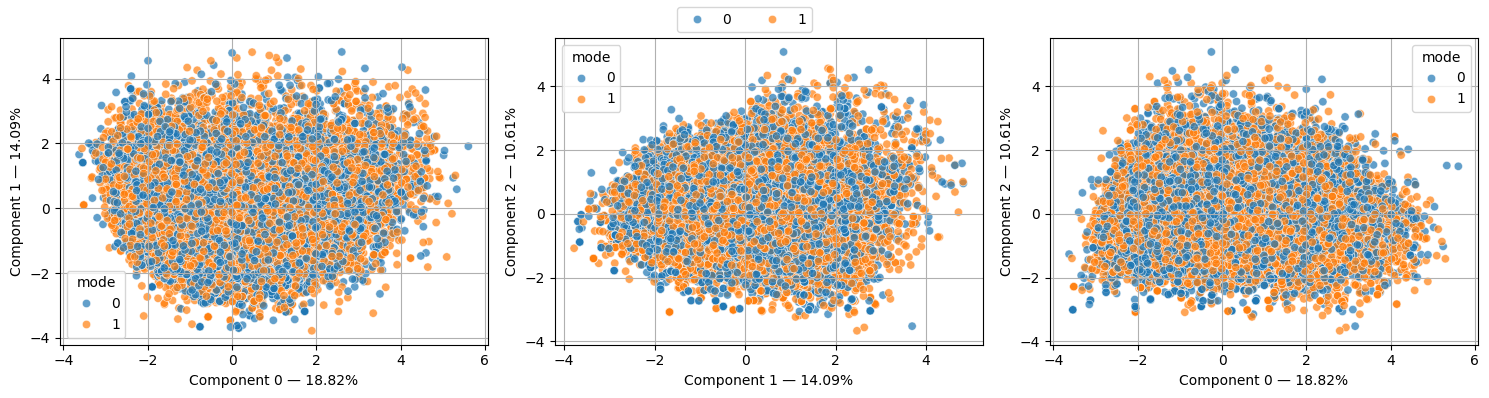

  
Qualitative variable : playlist_genre
Number of modalities: 6


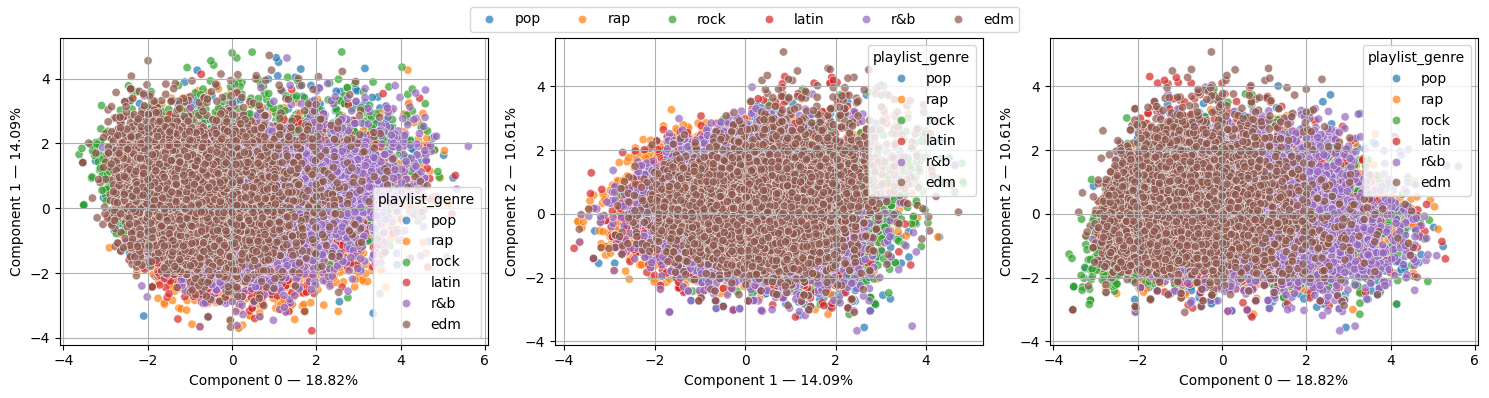

  
Qualitative variable : playlist_id
Number of modalities: 470
  
Qualitative variable : playlist_name
Number of modalities: 448
  
Qualitative variable : playlist_subgenre
Number of modalities: 24
  
Qualitative variable : track_album_id
Number of modalities: 18890
  
Qualitative variable : track_album_name
Number of modalities: 16737
  
Qualitative variable : track_album_release_date
Number of modalities: 4003
  
Qualitative variable : track_artist
Number of modalities: 9222
  
Qualitative variable : track_id
Number of modalities: 23195
  
Qualitative variable : track_name
Number of modalities: 19409


In [9]:
# FAIRE UN GRAPHE DES VALEURS QUANTITATIVES VS 1 VALEUR QUALITATIVE
def plot_pca(pca, ax1=0, ax2=1, hue=None, ax=None, data=df_quanti):
  dataset = pca.transform(data)
  # on ajoute la variable playlist_genre dans notre base de données quantitatives
  dataset[hue] = df_clean[hue].values
  dataset.reset_index(inplace=True)
  sns.scatterplot(data = dataset,
                  x = ax1, y = ax2,
                  hue = hue, alpha=.7, ax=ax)

  ax.set_xlabel('Component {} — {:.2f}%'.format(ax1, pca.percentage_of_variance_[ax1]))
  ax.set_ylabel('Component {} — {:.2f}%'.format(ax2, pca.percentage_of_variance_[ax2]))
  ax.grid(True)

# REGROUPER 3 GRAPHES POUR UNE MÊME VALEUR QUALITATIVE AVEC DES COMBINAISONS DIFFÉRENTES DE COMPOSANTES PRINCIPALES
def plot_several(pca,hue):
    # Set up 1x3 subplot grid
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))  # smaller width per plot
    plt.subplots_adjust(wspace=0.3)  # spacing between plots

    plot_pca(pca, 0,1, hue=hue,ax=axes[0],data=df_quanti)
    plot_pca(pca, 1,2, hue=hue,ax=axes[1],data=df_quanti)
    plot_pca(pca, 0,2, hue=hue,ax=axes[2],data=df_quanti)
    
    handles, labels = axes[2].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=len(labels), frameon=True)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for the legend
    plt.show()

# BOUCLE SUR TOUTES LES VALEURS QUALITATIVES QUI ONT MOINS DE N MODALITÉS
qual_features = df_clean.columns.difference(numeric_features)
N = 15
for qual_var in qual_features :
    num_modalities = df_clean[qual_var].nunique()
    print('  ')
    print(f"Qualitative variable : {qual_var}")
    print("Number of modalities:", num_modalities)
    if num_modalities<N :
        plot_several(pca,hue=qual_var)
# --- #

The only two quantitative variables we study are the mode and the playlist genre as they have under 15 modalities which could still be interpretable. However, we do not see a clear distinction between the different classes, at least for the mode variable. Fot the playlist genre we can observe some clusters of points that we could try to separate using non-linear SVM.

## Multiple Correspondence Analysis

MCA is the usual dimension reduction technique when working with qualitative variables.

In [10]:
df_quali = df[qual_features] 
df_quali = df_quali.astype('category')

pd.get_dummies(df_quali)

,key_0,key_1,key_2,key_3,key_4,key_5,key_6,key_7,key_8,key_9,...,track_name_真っ赤な太陽,track_name_貴方しか見えない,track_name_贅沢な罠,track_name_霧のDOWN TOWN,track_name_달라달라 DALLA DALLA,track_name_숙녀 (淑女) Lady,track_name_쉼표,track_name_중독 Overdose,track_name_피카부 Peek-A-Boo,track_name_하드캐리 Hard Carry
0,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
32829,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
32830,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
32831,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


We will restrict our data set to the following qualitative variables: mode (2 modalities), playlist_genre (6 modalities) and playlist_subgenre (24 modalities). Then we will fit our model using MCA.


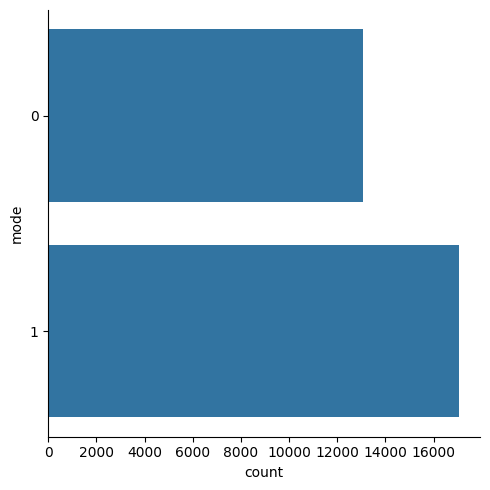

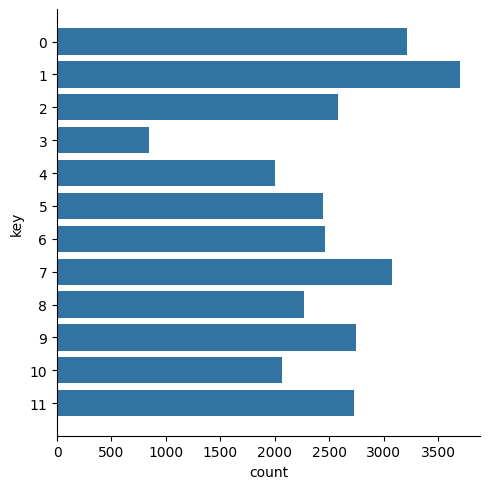

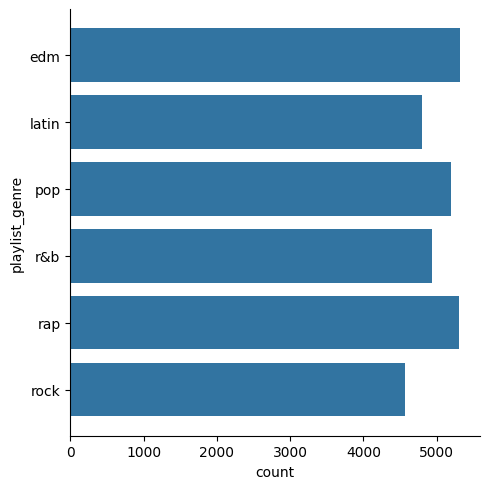

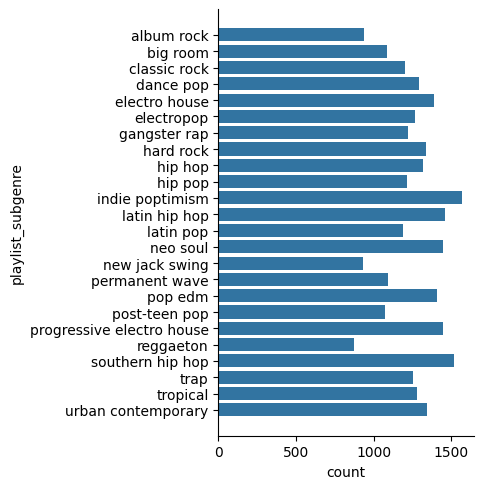

In [11]:
quali_features_restricted = ['mode','key','playlist_genre','playlist_subgenre']
df_quali_restricted = df_clean[quali_features_restricted]

for var in df_quali_restricted :
    sns.catplot(df[var].astype('category'), kind='count')
    plt.plot()



In [12]:
# PERFORM MCA
mca = prince.MCA(
    n_components=18,
    n_iter=10,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)
mca = mca.fit(df_quali_restricted)

In [22]:
pd.get_dummies(df_quali_restricted)

,key,mode_False,mode_True,playlist_genre_edm,playlist_genre_latin,playlist_genre_pop,playlist_genre_r&b,playlist_genre_rap,playlist_genre_rock,playlist_subgenre_album rock,...,playlist_subgenre_new jack swing,playlist_subgenre_permanent wave,playlist_subgenre_pop edm,playlist_subgenre_post-teen pop,playlist_subgenre_progressive electro house,playlist_subgenre_reggaeton,playlist_subgenre_southern hip hop,playlist_subgenre_trap,playlist_subgenre_tropical,playlist_subgenre_urban contemporary
0,6,False,True,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,11,False,True,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,True,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,7,False,True,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1,False,True,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32827,5,False,True,True,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
32828,2,False,True,True,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
32829,0,False,True,True,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
32830,6,True,False,True,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False


In [14]:
# tranform mode into a CATEGORY
print(df_quali_restricted.columns)
df_quali_restricted['mode'] = df_quali_restricted['mode'].astype(bool)
mode_dummies = pd.get_dummies(df_quali_restricted['mode'], prefix='mode')
df_quali_restricted = df_quali_restricted.drop(columns=['mode'])
df_quali_restricted = pd.concat([df_quali_restricted, mode_dummies], axis=1)

Index(['mode', 'key', 'playlist_genre', 'playlist_subgenre'], dtype='str')


In [15]:
pd.get_dummies(df_quali_restricted)


,key,mode_False,mode_True,playlist_genre_edm,playlist_genre_latin,playlist_genre_pop,playlist_genre_r&b,playlist_genre_rap,playlist_genre_rock,playlist_subgenre_album rock,...,playlist_subgenre_new jack swing,playlist_subgenre_permanent wave,playlist_subgenre_pop edm,playlist_subgenre_post-teen pop,playlist_subgenre_progressive electro house,playlist_subgenre_reggaeton,playlist_subgenre_southern hip hop,playlist_subgenre_trap,playlist_subgenre_tropical,playlist_subgenre_urban contemporary
0,6,False,True,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,11,False,True,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,True,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,7,False,True,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1,False,True,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32827,5,False,True,True,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
32828,2,False,True,True,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
32829,0,False,True,True,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
32830,6,True,False,True,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False


In [16]:
import pandas as pd
from sklearn.cluster import KMeans

def get_mca_modality_clusters(mca, data, n_clusters=5, n_components=3):
    """
    Cluster MCA modalities using their coordinates on the first n_components axes.

    Parameters
    ----------
    mca : fitted MCA object
        Your fitted MCA model.
    data : pandas.DataFrame
        Qualitative dataframe used to fit MCA.
    n_clusters : int
        Number of clusters wanted.
    n_components : int
        Number of MCA dimensions used for clustering.

    Returns
    -------
    coords : DataFrame
        Coordinates of modalities with assigned cluster.
    cluster_dict : dict
        Dictionary {cluster_id: list of modalities}
    """

    # Get coordinates of modalities
    # For prince MCA this usually works:
    coords = mca.column_coordinates(data).copy()

    # Keep only first n_components axes
    coords_used = coords.iloc[:, :n_components].copy()

    # Drop rows with NaN values to avoid KMeans error
    coords_used = coords_used.dropna()

    # KMeans clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    coords_used["cluster"] = kmeans.fit_predict(coords_used)

    # Keep full coords + cluster, but only for non-NaN
    result = coords.loc[coords_used.index].copy()
    result["cluster"] = coords_used["cluster"]

    # Build dictionary cluster -> list of modalities
    cluster_dict = {}
    for cl in sorted(result["cluster"].unique()):
        cluster_dict[cl] = result[result["cluster"] == cl].index.tolist()

    return result, cluster_dict



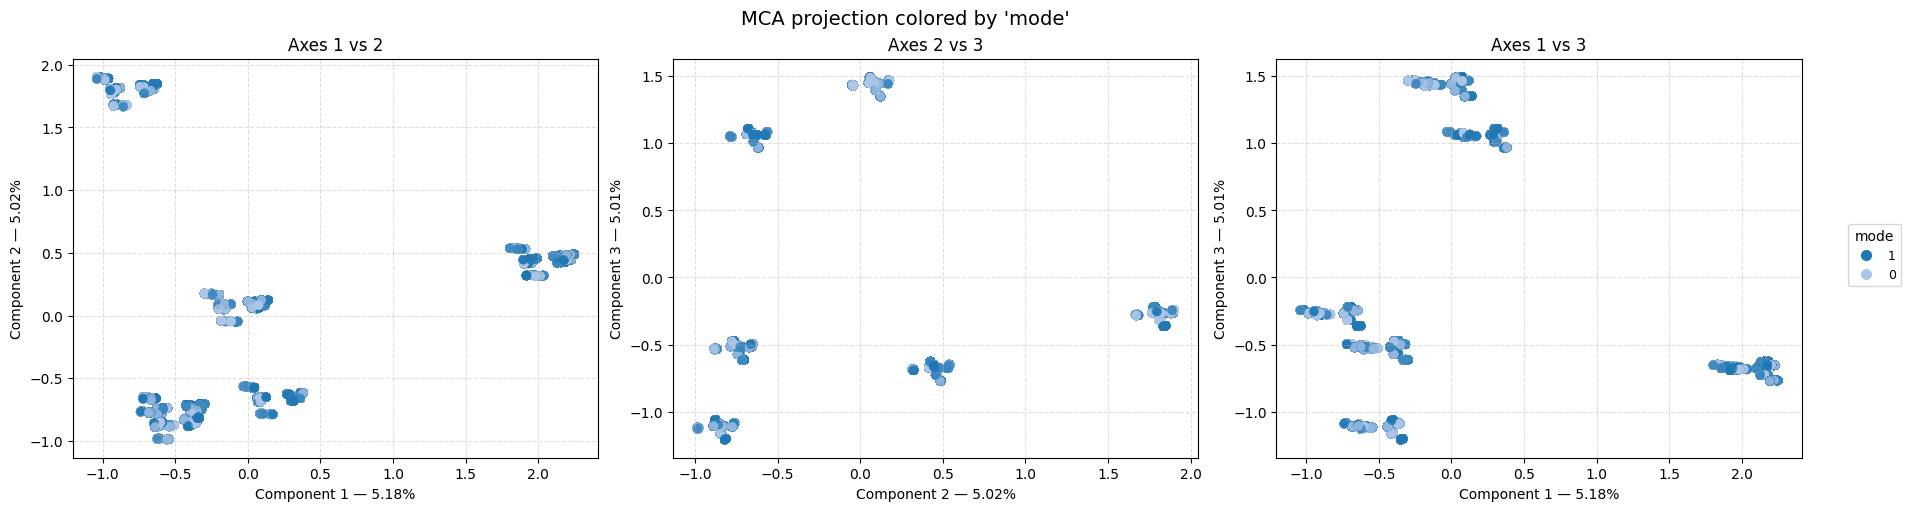

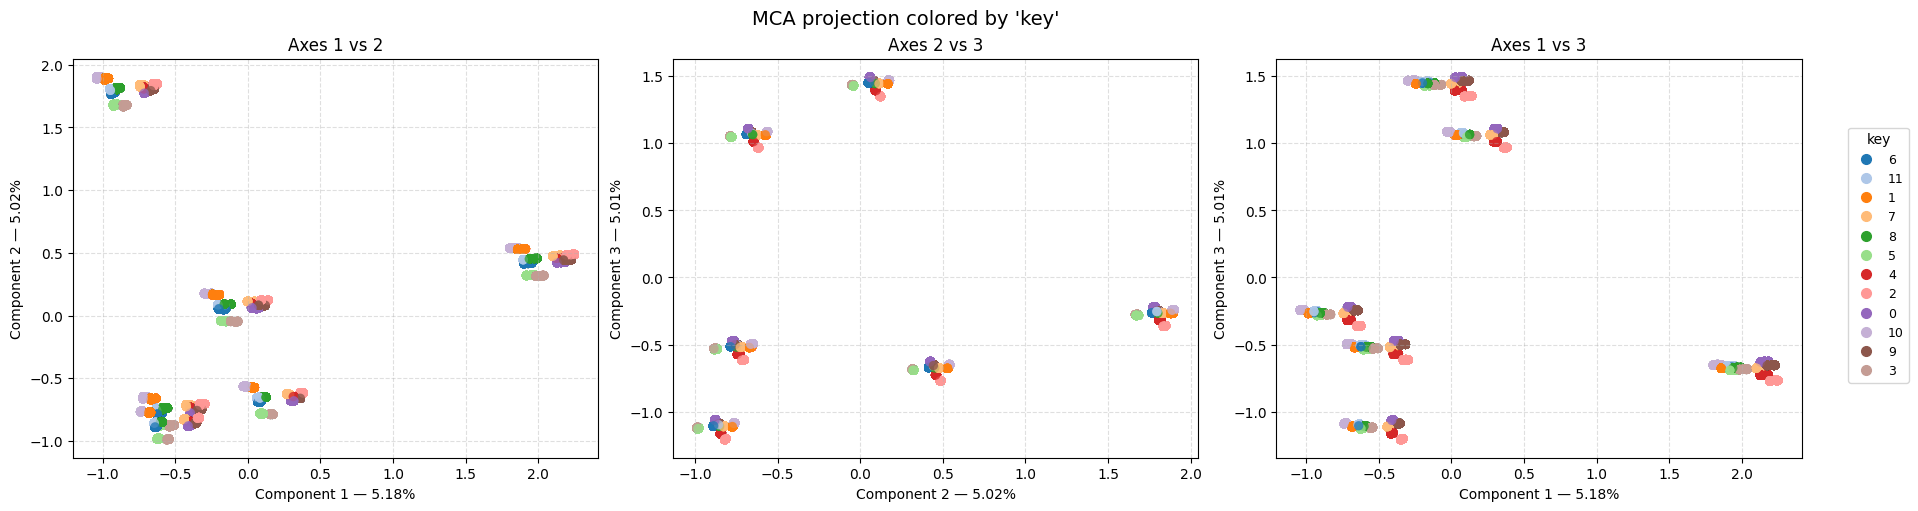

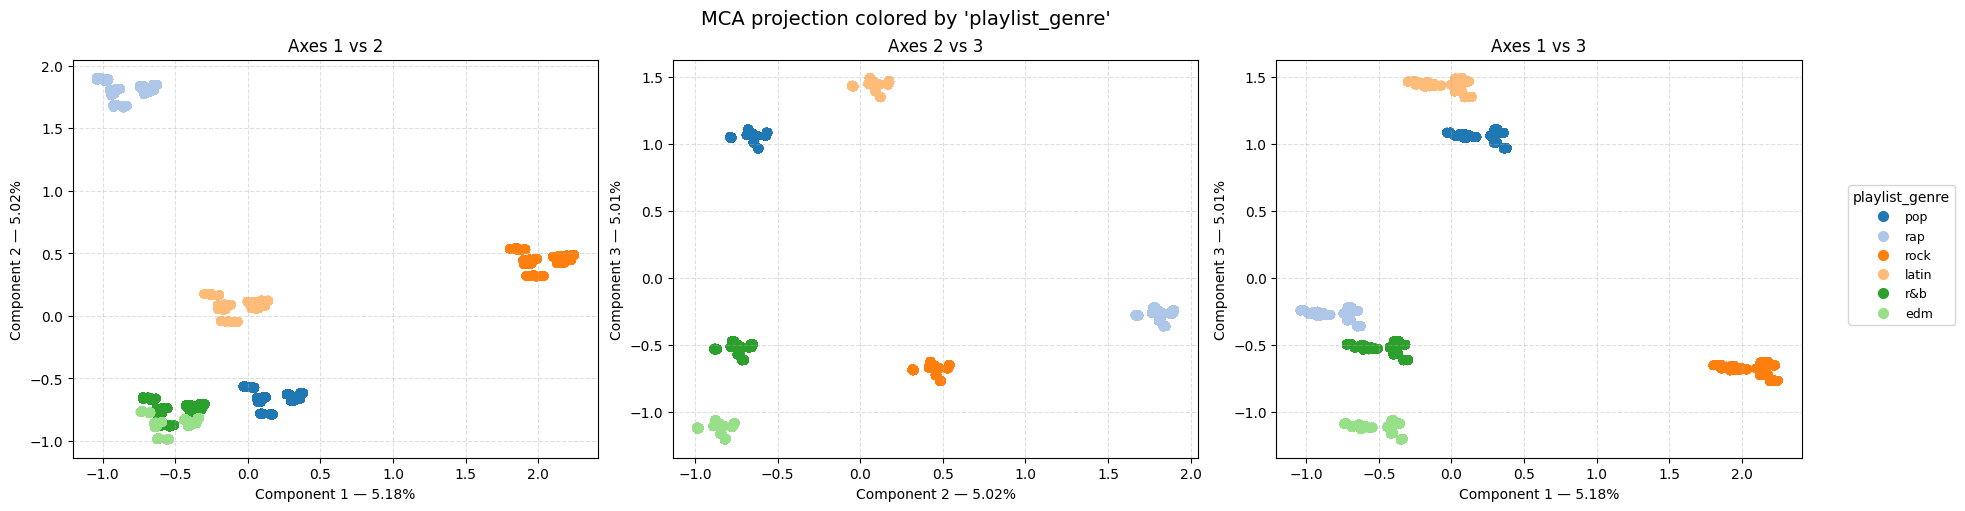

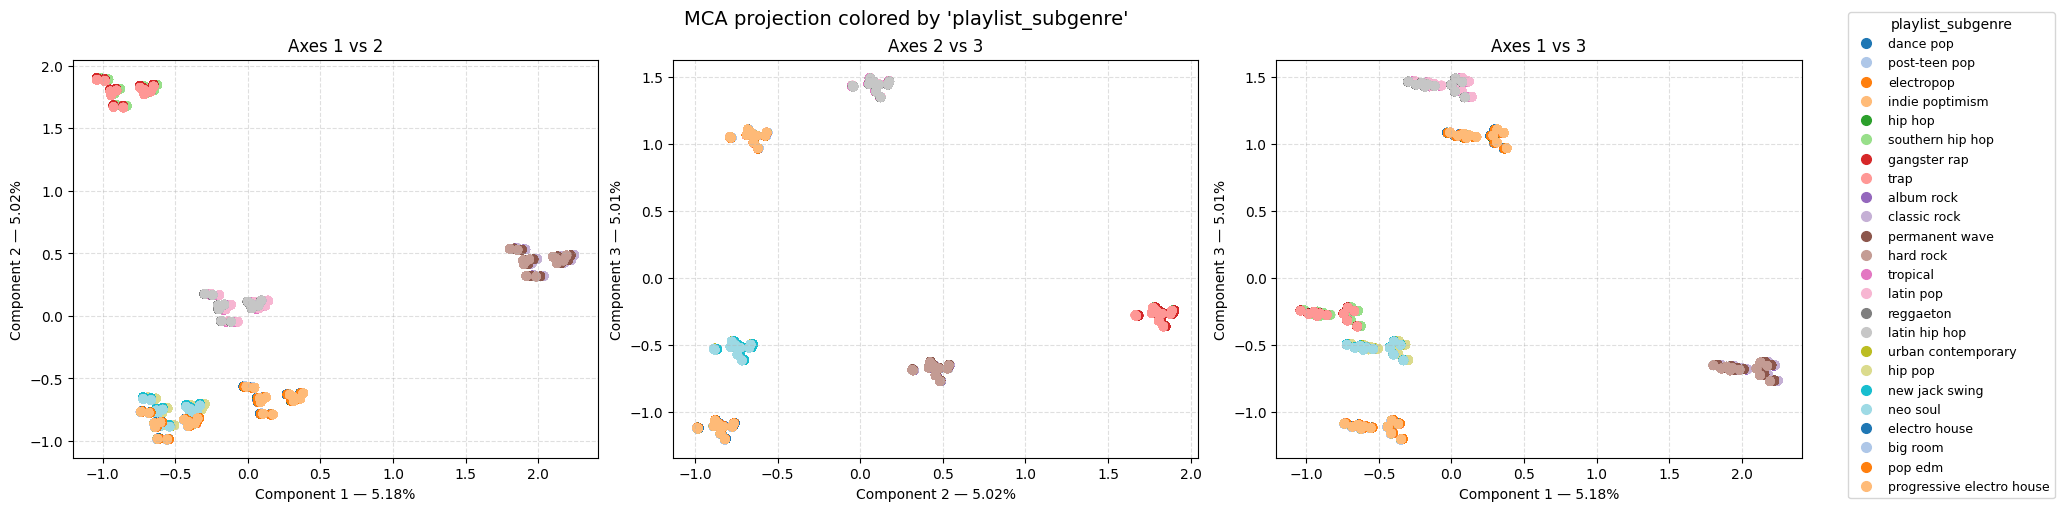

MCA modality clusters:


c:\Users\lenovoyoga914\Desktop\4A\S2\AD\musique\.venv\Lib\site-packages\prince\ca.py:223: RuntimeWarning: invalid value encountered in divide
  X = X.T / X.T.sum(axis=1)[:, None]


{np.int32(0): ['playlist_subgenre__gangster rap', 'playlist_subgenre__hip hop', 'playlist_subgenre__southern hip hop', 'playlist_subgenre__trap'], np.int32(1): ['playlist_subgenre__dance pop', 'playlist_subgenre__electropop', 'playlist_subgenre__indie poptimism', 'playlist_subgenre__latin hip hop', 'playlist_subgenre__latin pop', 'playlist_subgenre__post-teen pop', 'playlist_subgenre__reggaeton', 'playlist_subgenre__tropical'], np.int32(2): ['mode_False__False', 'mode_False__True', 'mode_True__False', 'mode_True__True'], np.int32(3): ['playlist_subgenre__album rock', 'playlist_subgenre__classic rock', 'playlist_subgenre__hard rock', 'playlist_subgenre__permanent wave'], np.int32(4): ['playlist_subgenre__big room', 'playlist_subgenre__electro house', 'playlist_subgenre__hip pop', 'playlist_subgenre__neo soul', 'playlist_subgenre__new jack swing', 'playlist_subgenre__pop edm', 'playlist_subgenre__progressive electro house', 'playlist_subgenre__urban contemporary']}


,modality,cluster
12,playlist_subgenre__hip hop,0
10,playlist_subgenre__gangster rap,0
24,playlist_subgenre__southern hip hop,0
25,playlist_subgenre__trap,0
9,playlist_subgenre__electropop,1
15,playlist_subgenre__latin hip hop,1
7,playlist_subgenre__dance pop,1
14,playlist_subgenre__indie poptimism,1
21,playlist_subgenre__post-teen pop,1
16,playlist_subgenre__latin pop,1


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# GRAPH OF QUALITATIVE VALUES
def plot_mca(mca, ax1=0, ax2=1, hue=None, ax=None, data=df_quali_restricted):
    dataset = mca.transform(data).copy()
    
    # add the qualitative variable
    dataset[hue] = df_clean[hue].values
    dataset = dataset.reset_index(drop=True)

    sns.scatterplot(
        data=dataset,
        x=ax1,
        y=ax2,
        hue=hue,
        ax=ax,
        alpha=0.75,
        s=45,              # point size
        edgecolor="none",
        legend=False       # remove legend from each subplot
    )

    ax.set_xlabel(f'Component {ax1+1} — {mca.percentage_of_variance_[ax1]:.2f}%')
    ax.set_ylabel(f'Component {ax2+1} — {mca.percentage_of_variance_[ax2]:.2f}%')
    ax.set_title(f'Axes {ax1+1} vs {ax2+1}')
    ax.grid(True, linestyle='--', alpha=0.4)


# GROUP 3 PLOTS FOR THE SAME QUALITATIVE VARIABLE
def plot_several(mca, hue, data):
    # prepare transformed data once
    dataset = mca.transform(data).copy()
    dataset[hue] = df_clean[hue].values
    dataset = dataset.reset_index(drop=True)

    # create figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

    # common palette
    categories = dataset[hue].dropna().unique()
    palette = sns.color_palette("tab20", n_colors=len(categories))
    palette_dict = dict(zip(categories, palette))

    # plot the 3 combinations
    for ax, (i, j) in zip(axes, [(0, 1), (1, 2), (0, 2)]):
        sns.scatterplot(
            data=dataset,
            x=i,
            y=j,
            hue=hue,
            palette=palette_dict,
            ax=ax,
            alpha=0.75,
            s=45,
            edgecolor="none",
            legend=False
        )
        ax.set_xlabel(f'Component {i+1} — {mca.percentage_of_variance_[i]:.2f}%')
        ax.set_ylabel(f'Component {j+1} — {mca.percentage_of_variance_[j]:.2f}%')
        ax.set_title(f'Axes {i+1} vs {j+1}')
        ax.grid(True, linestyle='--', alpha=0.4)

    # build one single legend outside
    handles = [
        plt.Line2D([], [], marker='o', linestyle='', color=palette_dict[cat], label=str(cat), markersize=7)
        for cat in categories
    ]

    fig.legend(
        handles=handles,
        labels=[str(cat) for cat in categories],
        title=hue,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        frameon=True,
        fontsize=9,
        title_fontsize=10
    )

    fig.suptitle(f"MCA projection colored by '{hue}'", fontsize=14)
    plt.show()


# LOOP ON ALL QUALITATIVE VARIABLES
for qual_var in quali_features_restricted:
    plot_several(mca, hue=qual_var, data=df_quali_restricted)


df_subgenre = df_quali_restricted['playlist_subgenre']
df_subgenre_pandas = pd.concat([df_subgenre, mode_dummies], axis=1)


print("MCA modality clusters:")
mca_coords, mca_clusters = get_mca_modality_clusters(mca, df_subgenre_pandas, n_clusters=5, n_components=3)
print(mca_clusters)

cluster_table = (
    mca_coords.reset_index()
    .rename(columns={"index": "modality"})
    .sort_values("cluster")
)

display(cluster_table[["modality", "cluster"]])

On ne peut pas tirer des conclusions. Vaut mieux regrouper toutes les colonnes genre en une seule colonne avec les modalités au lieu de TRue False. On va essayer d'appliquer une analyse en correspondance entre le mode et le genre.

### Popularity

Mean popularity by genre:
 playlist_genre
pop      0.503265
latin    0.502008
rap      0.466847
r&b      0.450697
rock     0.449591
edm      0.396195
Name: track_popularity, dtype: float64


C:\Users\lenovoyoga914\AppData\Local\Temp\ipykernel_31196\409691029.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean,


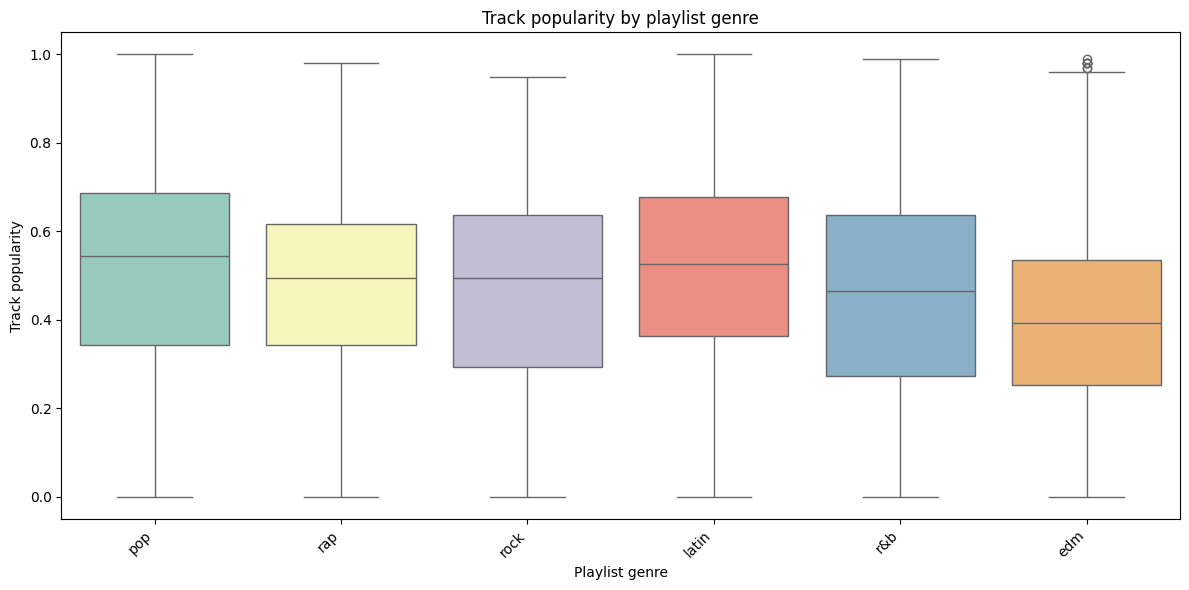

In [18]:
# basic statistics per genre
mean_pop = df_clean.groupby('playlist_genre')['track_popularity'] \
                   .mean() \
                   .sort_values(ascending=False)
print("Mean popularity by genre:\n", mean_pop)

# visual comparison
plt.figure(figsize=(12,6))
sns.boxplot(data=df_clean,
            x='playlist_genre',
            y='track_popularity',
            palette="Set3")
plt.xticks(rotation=45, ha='right')
plt.title('Track popularity by playlist genre')
plt.ylabel('Track popularity')
plt.xlabel('Playlist genre')
plt.tight_layout()
plt.show()


In [19]:
# Convert track_popularity into categories: low, medium, high
# Assuming track_popularity is scaled between 0 and 1
bins = [0, 0.33, 0.66, 1]
labels = ['low', 'medium', 'high']
df_clean['popularity_class'] = pd.cut(df_clean['track_popularity'], bins=bins, labels=labels, include_lowest=True)

quali_features_restricted = ['mode','key','playlist_genre','playlist_subgenre']

for quali_var in quali_features_restricted:
    # Build contingency table: rows = playlist_genre, columns = popularity_class
    contingency_table = pd.crosstab(df_clean[quali_var], df_clean['popularity_class'])

    print(f"Contingency Table: {quali_var} vs Popularity Class")
    print(contingency_table)

    """# Optional: Visualize with a heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(contingency_table, annot=True, cmap='Blues', fmt='d')
    plt.title('Contingency Table: Playlist Genre vs Popularity Class')
    plt.xlabel('Popularity Class')
    plt.ylabel(quali_var)
    plt.show()"""
    

Contingency Table: mode vs Popularity Class
popularity_class   low  medium  high
mode                                
0                 3243    6244  2398
1                 4176    7889  3379
Contingency Table: key vs Popularity Class
popularity_class  low  medium  high
key                                
0                 778    1511   618
1                 895    1734   760
2                 695    1177   463
3                 217     408   136
4                 503     898   400
5                 592    1158   468
6                 603    1172   466
7                 868    1385   541
8                 481    1140   454
9                 638    1293   540
10                473     996   374
11                676    1261   557
Contingency Table: playlist_genre vs Popularity Class
popularity_class   low  medium  high
playlist_genre                      
edm               1758    2551   524
latin              914    2313  1262
pop               1144    2310  1450
r&b               1379


ANALYSIS: key vs popularity_class

Chi-square test:
Chi2 statistic = 68.3399
Degrees of freedom = 22
p-value = 0.000001
Cramér's V = 0.0354


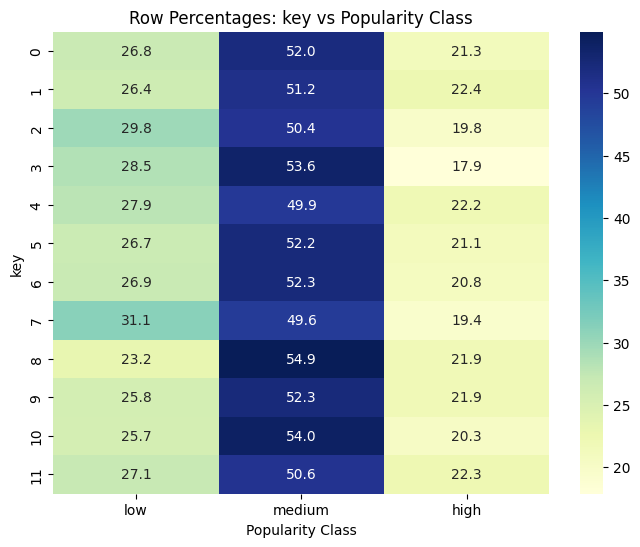

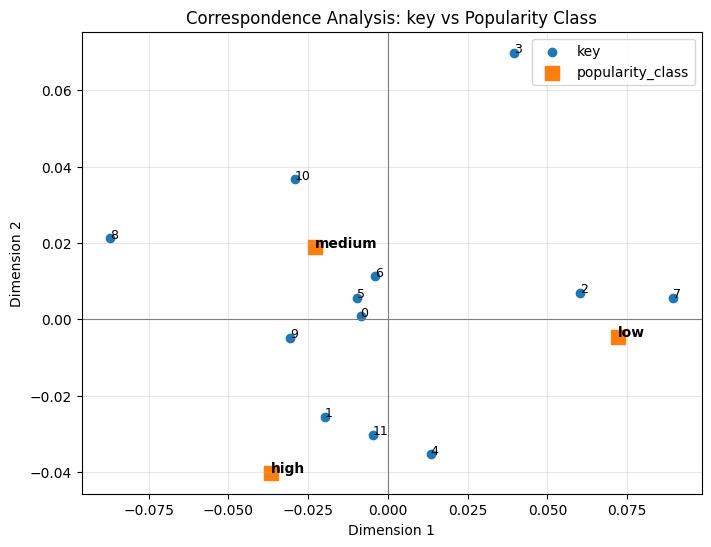


ANALYSIS: playlist_genre vs popularity_class

Chi-square test:
Chi2 statistic = 986.6294
Degrees of freedom = 10
p-value = 0.000000
Cramér's V = 0.1344


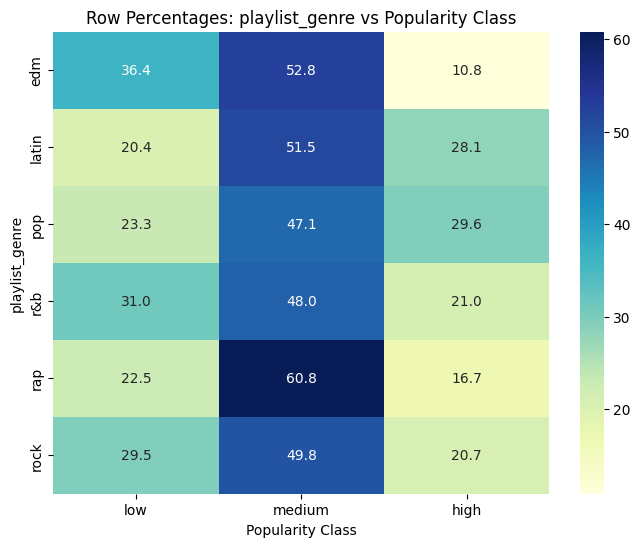

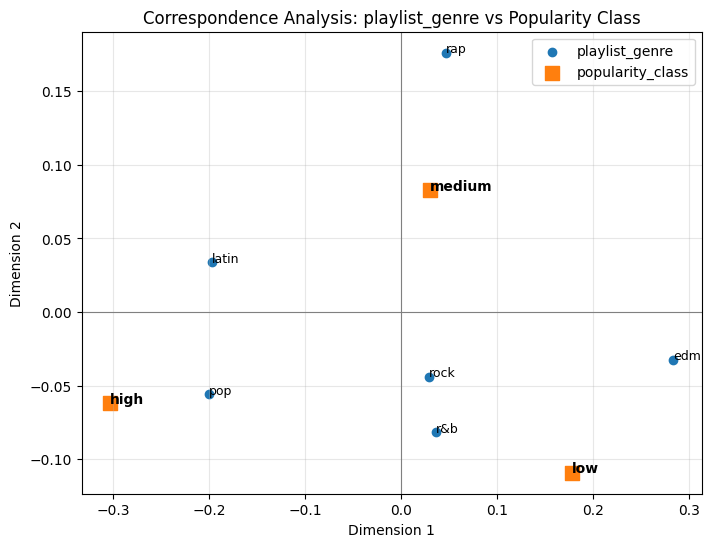


ANALYSIS: playlist_subgenre vs popularity_class

Chi-square test:
Chi2 statistic = 3618.8793
Degrees of freedom = 46
p-value = 0.000000
Cramér's V = 0.2573


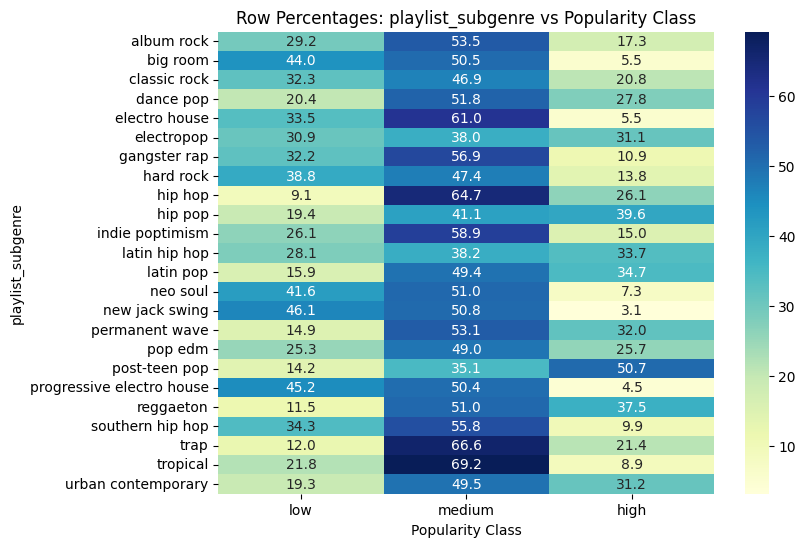

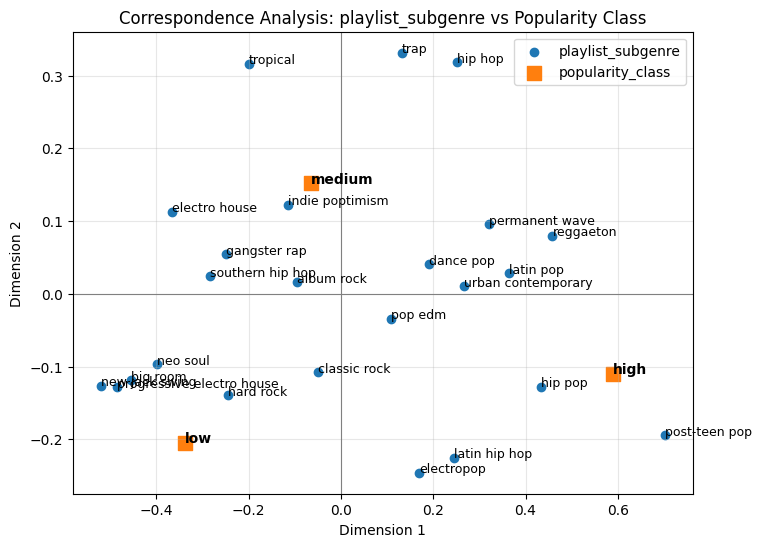

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
import prince

# ---------------------------------------------------
# 1. Create popularity classes
# ---------------------------------------------------
bins = [0, 0.33, 0.66, 1]
labels = ['low', 'medium', 'high']

df_clean['popularity_class'] = pd.cut(
    df_clean['track_popularity'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# qualitative variables to study
quali_features_restricted = ['key', 'playlist_genre', 'playlist_subgenre']

# ---------------------------------------------------
# 2. Function to compute Cramér's V
# ---------------------------------------------------
def cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.to_numpy().sum()
    r, k = contingency_table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

# ---------------------------------------------------
# 3. Full analysis loop
# ---------------------------------------------------
for quali_var in quali_features_restricted:
    print("\n" + "="*70)
    print(f"ANALYSIS: {quali_var} vs popularity_class")
    print("="*70)

    # contingency table
    contingency_table = pd.crosstab(df_clean[quali_var], df_clean['popularity_class'])

    # row percentages
    row_perc = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100

    # chi-square test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print("\nChi-square test:")
    print(f"Chi2 statistic = {chi2:.4f}")
    print(f"Degrees of freedom = {dof}")
    print(f"p-value = {p:.6f}")

    # Cramér's V
    v = cramers_v(contingency_table)
    print(f"Cramér's V = {v:.4f}")

    # standardized residuals
    residuals = (contingency_table - expected) / np.sqrt(expected)
    residuals = pd.DataFrame(
        residuals,
        index=contingency_table.index,
        columns=contingency_table.columns
    )


    """# ---------------------------------------------------
    # 4. Heatmap of counts
    # ---------------------------------------------------
    plt.figure(figsize=(8, 6))
    sns.heatmap(contingency_table, annot=True, cmap='Blues', fmt='d')
    plt.title(f'Counts: {quali_var} vs Popularity Class')
    plt.xlabel('Popularity Class')
    plt.ylabel(quali_var)
    plt.show()"""

    # ---------------------------------------------------
    # 5. Heatmap of row percentages
    # ---------------------------------------------------
    plt.figure(figsize=(8, 6))
    sns.heatmap(row_perc, annot=True, cmap='YlGnBu', fmt='.1f')
    plt.title(f'Row Percentages: {quali_var} vs Popularity Class')
    plt.xlabel('Popularity Class')
    plt.ylabel(quali_var)
    plt.show()

    """# ---------------------------------------------------
    # 6. Heatmap of standardized residuals
    # ---------------------------------------------------
    plt.figure(figsize=(8, 6))
    sns.heatmap(residuals, annot=True, cmap='coolwarm', center=0, fmt='.2f')
    plt.title(f'Standardized Residuals: {quali_var} vs Popularity Class')
    plt.xlabel('Popularity Class')
    plt.ylabel(quali_var)
    plt.show()"""

    # ---------------------------------------------------
    # 7. Correspondence Analysis
    # ---------------------------------------------------
    ca = prince.CA(n_components=2, random_state=42)
    ca = ca.fit(contingency_table)

    row_coords = ca.row_coordinates(contingency_table)
    col_coords = ca.column_coordinates(contingency_table)

    plt.figure(figsize=(8, 6))

    # row points
    plt.scatter(row_coords[0], row_coords[1], label=quali_var)
    for i, txt in enumerate(row_coords.index):
        plt.annotate(txt, (row_coords.iloc[i, 0], row_coords.iloc[i, 1]), fontsize=9)

    # column points
    plt.scatter(col_coords[0], col_coords[1], marker='s', s=100, label='popularity_class')
    for i, txt in enumerate(col_coords.index):
        plt.annotate(txt, (col_coords.iloc[i, 0], col_coords.iloc[i, 1]), fontsize=10, fontweight='bold')

    plt.axhline(0, color='grey', linewidth=0.8)
    plt.axvline(0, color='grey', linewidth=0.8)
    plt.title(f'Correspondence Analysis: {quali_var} vs Popularity Class')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
import prince

# ---------------------------------------------------
# 1. Create popularity classes
# ---------------------------------------------------
bins = [0, 0.33, 0.66, 1]
labels = ['low', 'medium', 'high']

initial_quantitative = 'loudness'
initial_quantitative_class = 'loudness_class'
df_clean[initial_quantitative] = pd.cut(
    df_clean[initial_quantitative],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print(df_clean[[initial_quantitative, initial_quantitative_class]].head())

# qualitative variables to study
quali_features_restricted = ['key', 'playlist_genre', 'playlist_subgenre']

# ---------------------------------------------------
# 2. Function to compute Cramér's V
# ---------------------------------------------------
def cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.to_numpy().sum()
    r, k = contingency_table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

# ---------------------------------------------------
# 3. Full analysis loop
# ---------------------------------------------------
for quali_var in quali_features_restricted:
    print("\n" + "="*70)
    print(f"ANALYSIS: {quali_var} vs {initial_quantitative}")
    print("="*70)

    # contingency table
    contingency_table = pd.crosstab(df_clean[quali_var], df_clean[initial_quantitative])

    # row percentages
    row_perc = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100

    # chi-square test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print("\nChi-square test:")
    print(f"Chi2 statistic = {chi2:.4f}")
    print(f"Degrees of freedom = {dof}")
    print(f"p-value = {p:.6f}")

    # Cramér's V
    v = cramers_v(contingency_table)
    print(f"Cramér's V = {v:.4f}")

    # standardized residuals
    residuals = (contingency_table - expected) / np.sqrt(expected)
    residuals = pd.DataFrame(
        residuals,
        index=contingency_table.index,
        columns=contingency_table.columns
    )


    """# ---------------------------------------------------
    # 4. Heatmap of counts
    # ---------------------------------------------------
    plt.figure(figsize=(8, 6))
    sns.heatmap(contingency_table, annot=True, cmap='Blues', fmt='d')
    plt.title(f'Counts: {quali_var} vs Popularity Class')
    plt.xlabel('Popularity Class')
    plt.ylabel(quali_var)
    plt.show()"""

    # ---------------------------------------------------
    # 5. Heatmap of row percentages
    # ---------------------------------------------------
    plt.figure(figsize=(8, 6))
    sns.heatmap(row_perc, annot=True, cmap='YlGnBu', fmt='.1f')
    plt.title(f'Row Percentages: {quali_var} vs {initial_quantitative}')
    plt.xlabel(f'{initial_quantitative}')
    plt.ylabel(quali_var)
    plt.show()

    """# ---------------------------------------------------
    # 6. Heatmap of standardized residuals
    # ---------------------------------------------------
    plt.figure(figsize=(8, 6))
    sns.heatmap(residuals, annot=True, cmap='coolwarm', center=0, fmt='.2f')
    plt.title(f'Standardized Residuals: {quali_var} vs Popularity Class')
    plt.xlabel('Popularity Class')
    plt.ylabel(quali_var)
    plt.show()"""

    # ---------------------------------------------------
    # 7. Correspondence Analysis
    # ---------------------------------------------------
    ca = prince.CA(n_components=2, random_state=42)
    ca = ca.fit(contingency_table)

    row_coords = ca.row_coordinates(contingency_table)
    col_coords = ca.column_coordinates(contingency_table)

    plt.figure(figsize=(8, 6))

    # row points
    plt.scatter(row_coords[0], row_coords[1], label=quali_var)
    for i, txt in enumerate(row_coords.index):
        plt.annotate(txt, (row_coords.iloc[i, 0], row_coords.iloc[i, 1]), fontsize=9)

    # column points
    plt.scatter(col_coords[0], col_coords[1], marker='s', s=100, label=initial_quantitative)
    for i, txt in enumerate(col_coords.index):
        plt.annotate(txt, (col_coords.iloc[i, 0], col_coords.iloc[i, 1]), fontsize=10, fontweight='bold')

    plt.axhline(0, color='grey', linewidth=0.8)
    plt.axvline(0, color='grey', linewidth=0.8)
    plt.title(f'Correspondence Analysis: {quali_var} vs {initial_quantitative}')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

KeyError: "['loudness_class'] not in index"

### CA 


In [ ]:
df_ca = df_clean.copy()
df_ca['mode'] = df_clean['mode'].map({0: 'Minor', 1: 'Major'})

table = pd.crosstab(df_clean['playlist_genre'], df_clean['mode'])
table

mode,0,1
playlist_genre,,
edm,2327,2506
latin,1938,2551
pop,2032,2872
r&b,2138,2316
rap,2237,2408
rock,1213,2791
